# Exonmask effect magnitude vs gene expression in skeletal muscle for ClinGen cohort

investigate the relationship between AlphaGenome exonmask variant effect sizes and gene expression levels in skeletal muscle tissue for ClinGen-curated muscle disease genes.

### Dataset used

316 genes from ClinGen gene curation that are scored with Alphagenome exonmask.

### Initial hypothesis 

 Genes with higher expression in skeletal muscle may show larger absolute AlphaGenome effect sizes (|Δlog₂|) because:
1. highly expressed genes are more functionally constrained
2. variants disrupting highly expressed genes may have larger predicted functional impact
3. alternatively, expression-insensitive housekeeping functions could show opposite pattern

### Methods 

- AlphaGenome scores: exonmask method (gene-level delta log₂ predictions)
- expression: GTEx v10 median TPM in skeletal muscle
- analysis: Spearman correlation between mean |Δlog₂| per gene and log₁₀(TPM+1)

## Results 

Two main ones:

1. Highly expressed genes are strongly buffered against perturbations.

Across all effect metrics (mean, median, top-decile), variant impact decreases sharply with increasing expression.
This relationship renanied robust after controlling for gene length and variant density, indicating that expression level itself is the dominant predictor of small perturbation effects.

2. Gene architecture modulates effect size independently of expression.

Shorter genes and genes with higher variant density show larger average effects.
These structural predictors remain significant after accounting for expression, showing that compact and densely mutated genes are intrinsically more sensitive to sequence changes.

3. Effects within individual genes are highly concentrated.

Most genes show strong internal heterogeneity:
* the top 10% of variants carry ~60–70% of total effect,
* effect distributions are highly right-skewed,
* several genes harbor extreme regulatory “hotspots.”
This concentration pattern is independent of expression, showing gene-specific architecture rather than transcriptional state.

4. Signed effects show no global directionality bias.

Mean signed effects per gene are nearly zero; only one gene shows a clear directional shift, confirming the assay has no systematic up/down bias and validating the use of absolute effect magnitude.

5. Promoter- and exon-level signals align, but exons dominate the analysis.

Promoter view effects show the same expression–buffering relationship, but sparse center/promoter windows add little beyond the exonmask signal.

So to conclude our analusis
1. Transcriptional buffering: highly expressed genes are intrinsically resistant to perturbation.
2. Local architectural sensitivity: shorter and densely mutated genes show concentrated hotspots of regulatory impact.

## 1. Setup

In [130]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# plotting style
sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


### 1.1. load preprocessed gene-level data

this CSV was generated by streaming 180M variant-level AlphaGenome scores and aggregating:

In [131]:
# path to preprocessed data
data_path = Path('/Users/markus/university/ML-in-biotech-CB206V-ws25/data/results/ClinGen/gene_level_data_extended.csv')

# load
df = pd.read_csv(data_path)

print(f'loaded {len(df):,} genes')
print(f'columns: {", ".join(df.columns)}')
df.head()

loaded 316 genes
columns: gene_id, n_variants_exon, mean_abs_effect_exon, median_abs_effect_exon, std_abs_effect_exon, min_abs_effect_exon, max_abs_effect_exon, mean_signed_effect_exon, min_variant_id, min_variant_score, max_variant_id, max_variant_score, mean_dist_to_tss, median_dist_to_tss, min_dist_to_tss, max_dist_to_tss, top10pct_effect_fraction, cv_effect, skewness_effect, mean_effect_top_decile, mean_effect_bottom_decile, variants_per_kb, frac_high_impact_0.5, frac_high_impact_1.0, n_variants_up2kb, mean_abs_effect_up2kb, median_abs_effect_up2kb, max_abs_effect_up2kb, n_variants_up10kb, mean_abs_effect_up10kb, median_abs_effect_up10kb, max_abs_effect_up10kb, n_variants_up100kb, mean_abs_effect_up100kb, median_abs_effect_up100kb, max_abs_effect_up100kb, n_variants_down2kb, mean_abs_effect_down2kb, n_variants_intron2kb, mean_abs_effect_intron2kb, enrich_up_vs_down_2kb, enrich_up_vs_intron_2kb, distance_decay_slope, mean_abs_effect_promo, n_variants_promo, mean_abs_effect_center, n

,gene_id,n_variants_exon,mean_abs_effect_exon,median_abs_effect_exon,std_abs_effect_exon,min_abs_effect_exon,max_abs_effect_exon,mean_signed_effect_exon,min_variant_id,min_variant_score,...,enrich_up_vs_down_2kb,enrich_up_vs_intron_2kb,distance_decay_slope,mean_abs_effect_promo,n_variants_promo,mean_abs_effect_center,n_variants_center,tpm,log10_tpm1,gene_length
0,ENSG00000003400,9296,0.007704,0.001373,0.020000,0.000000e+00,0.363131,-0.000528,chr2:201179007:T>C,0.000000e+00,...,0.624905,0.624905,-0.000556,0.011303,1862.0,NaN,NaN,1.382510,0.377035,46557.0
1,ENSG00000005339,14572,0.002320,0.000743,0.004782,8.940697e-08,0.073222,-0.000153,chr16:3889350:TTCCCTTCCCCTTCCTTCCTTCTCTCCTTTCT...,8.940697e-08,...,0.491259,0.490523,-0.001928,0.003948,3350.0,NaN,NaN,19.052800,1.302175,155660.0
2,ENSG00000005483,12272,0.003156,0.000730,0.006252,0.000000e+00,0.091508,-0.000111,chr7:105023375:C>T,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.766580,1.032078,174077.0
3,ENSG00000007168,13310,0.003512,0.000731,0.007803,2.384186e-07,0.287291,-0.000047,chr17:2583994:T>G,-2.384186e-07,...,0.474188,0.474188,-0.000368,0.005534,2984.0,NaN,NaN,50.904400,1.715204,92433.0
4,ENSG00000007372,11274,0.003253,0.001476,0.005264,0.000000e+00,0.092383,0.000122,chr11:31807451:C>T,0.000000e+00,...,0.815291,0.815291,-0.002161,0.002633,2240.0,NaN,NaN,0.008973,0.003880,33183.0


## 1.2. data overview

In [132]:
# summary statistics
print('summary statistics:')
print()
print(df[['mean_abs_effect_exon', 'n_variants_exon', 'tpm', 'gene_length']].describe())

# check for missing data
#print('\nmissing data:')
#print(df.isnull().sum())

summary statistics:

       mean_abs_effect_exon  n_variants_exon          tpm   gene_length
count            316.000000       316.000000   316.000000  3.160000e+02
mean               0.006049     13537.601266    20.423252  1.780659e+05
std                0.003782      5671.839394    71.761778  2.992773e+05
min                0.000825      8218.000000     0.000000  2.512000e+03
25%                0.003420     10225.500000     0.422381  3.288175e+04
50%                0.004917     11268.000000     4.670185  8.351850e+04
75%                0.007591     13388.000000    15.354675  1.862755e+05
max                0.029266     35482.000000  1014.450000  2.304997e+06


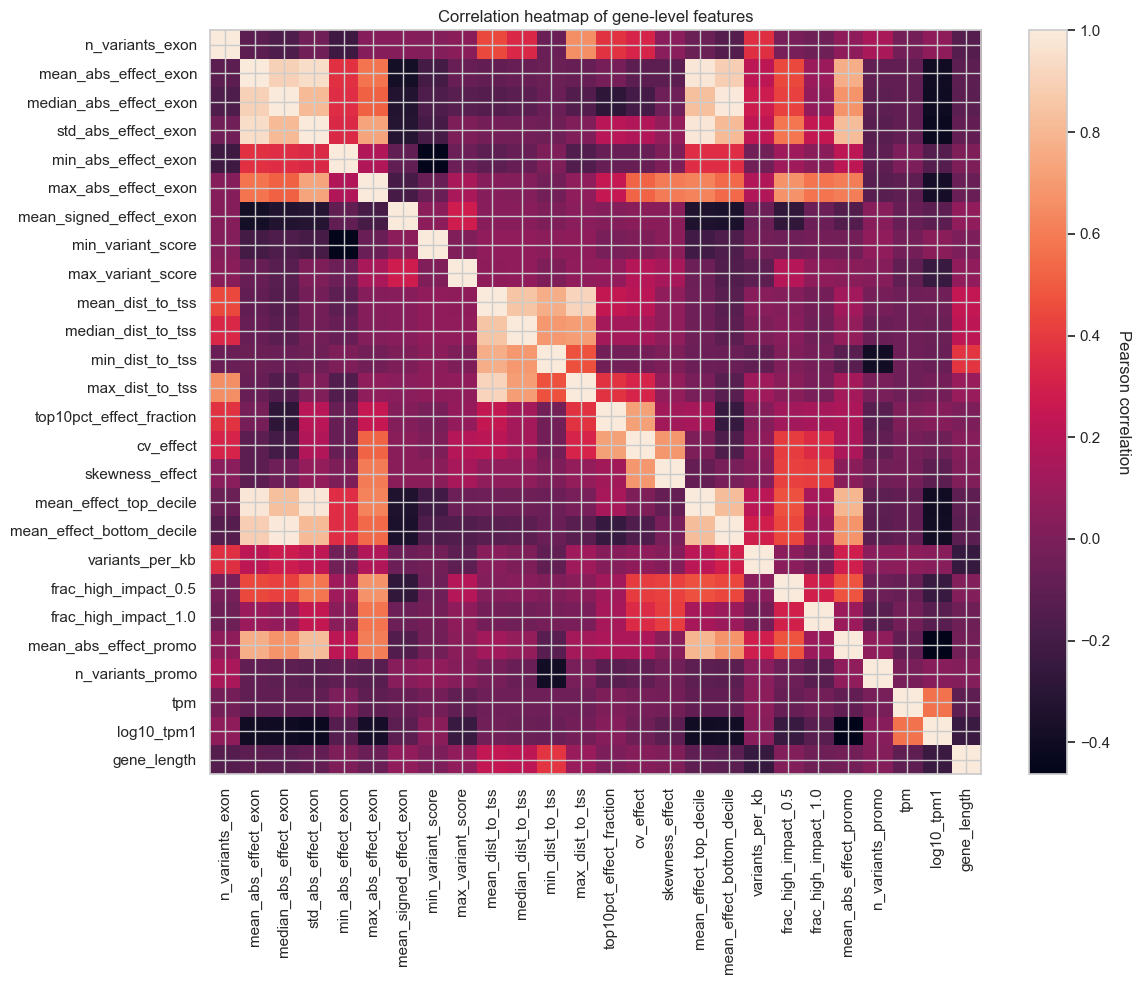

In [181]:
cols = [
    "n_variants_exon",
    "mean_abs_effect_exon",
    "median_abs_effect_exon",
    "std_abs_effect_exon",
    "min_abs_effect_exon",
    "max_abs_effect_exon",
    "mean_signed_effect_exon",

    "min_variant_id",       
    "min_variant_score",

    "max_variant_id",
    "max_variant_score",

    "mean_dist_to_tss",
    "median_dist_to_tss",
    "min_dist_to_tss",
    "max_dist_to_tss",

    "top10pct_effect_fraction",
    "cv_effect",
    "skewness_effect",
    "mean_effect_top_decile",
    "mean_effect_bottom_decile",

    "variants_per_kb",

    "frac_high_impact_0.5",
    "frac_high_impact_1.0",

    "mean_abs_effect_promo",
    "n_variants_promo",
    "tpm",
    "log10_tpm1",
    "gene_length",
]
#     "mean_abs_effect_center",
#     "n_variants_center",



cols_existing = [c for c in cols if c in df.columns]
df_num = df[cols_existing].select_dtypes(include=[np.number])

# Compute correlation matrix
corr = df_num.corr(method="pearson")

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, aspect="auto")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation", rotation=270, labelpad=15)

# Set ticks and labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)

ax.set_title("Correlation heatmap of gene-level features")
plt.tight_layout()
plt.show()

Basically what we  can see here

Signals should be present

* Expression lowers effect size 
* Gene length lowers effect size 
* Variant density increaseds and effect concentration
* Hotspot index genes
* Minimal promoter/exon cross-signal worth a short comparison

No singal
* Distance-to-TSS metrics (no relationship to effect size)
* Signed effect averages (noise, no pattern)
* Min/max variant scores except as sanity checks

## 2. Exonmask effect magnitude vs expression

**metric**: Spearman rank correlation (non-parametric, robust to outliers)

In [134]:
# prepare data for analysis
analysis_df = df[['log10_tpm1', 'mean_abs_effect_exon']].dropna().copy()
analysis_df = analysis_df.sort_values('log10_tpm1')

x = analysis_df['log10_tpm1'].values
y = analysis_df['mean_abs_effect_exon'].values

# compute spearman correlation
rho, p_value = spearmanr(x, y)

print(f'n = {len(analysis_df):,} genes')
print(f'Spearman ρ = {rho:.4f}')
print(f'p-value = {p_value:.2e}')
print()

n = 316 genes
Spearman ρ = -0.4484
p-value = 4.89e-17



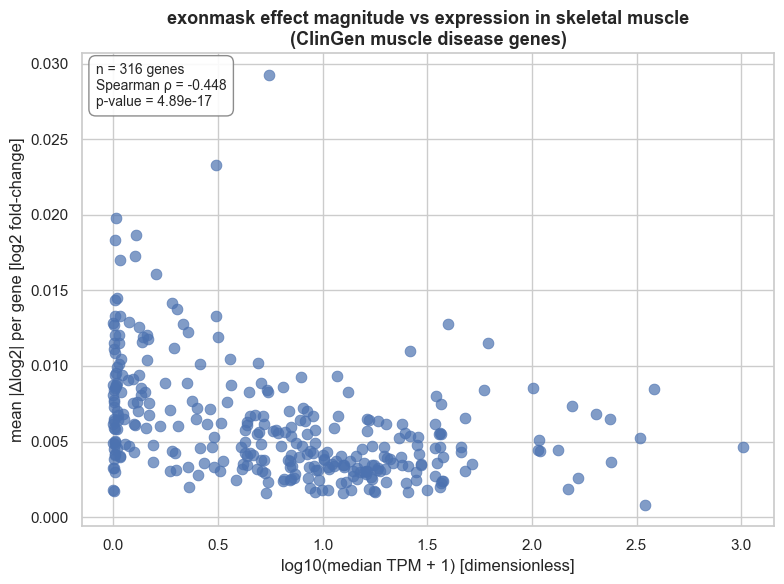

In [135]:
fig, ax = plt.subplots(figsize=(8, 6))

# scatter plot
sns.scatterplot(
    x=x, 
    y=y, 
    s=60, 
    alpha=0.7, 
    color='#4C72B0', 
    edgecolor=None, 
    ax=ax
)

# axis labels with units
ax.set_xlabel('log10(median TPM + 1) [dimensionless]', fontsize=12)
ax.set_ylabel('mean |Δlog2| per gene [log2 fold-change]', fontsize=12)
ax.set_title(
    'exonmask effect magnitude vs expression in skeletal muscle\n(ClinGen muscle disease genes)',
    fontsize=13,
    fontweight='bold'
)

# add statistics box
stats_text = f'n = {len(analysis_df):,} genes\nSpearman ρ = {rho:.3f}\np-value = {p_value:.2e}'
ax.text(
    0.02, 0.98,
    stats_text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        boxstyle='round,pad=0.5',
        alpha=0.9
    ),
    fontsize=10
)
plt.tight_layout()
plt.show()

* Negative correlation detected
* Higher expression associates with smaller effect magnitudes

## 3. Expression and effect distributions

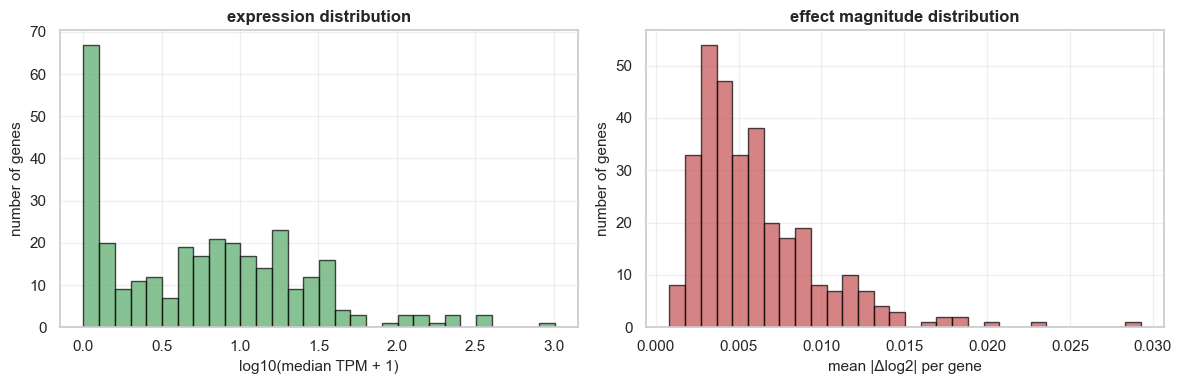

In [136]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# TPM distribution (log scale)
ax1.hist(df['log10_tpm1'].dropna(), bins=30, color='#55A868', alpha=0.7, edgecolor='black')
ax1.set_xlabel('log10(median TPM + 1)', fontsize=11)
ax1.set_ylabel('number of genes', fontsize=11)
ax1.set_title('expression distribution', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# effect size distribution
ax2.hist(df['mean_abs_effect_exon'].dropna(), bins=30, color='#C44E52', alpha=0.7, edgecolor='black')
ax2.set_xlabel('mean |Δlog2| per gene', fontsize=11)
ax2.set_ylabel('number of genes', fontsize=11)
ax2.set_title('effect magnitude distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Add TPM filter here

In [183]:
df_filt = df[df['tpm'] >= 0.1].copy()
print(f'filtered to {len(df_filt):,} genes with tpm >= 0.1 (removed {len(df) - len(df_filt)} genes)')
print(f'expression range: {df_filt["tpm"].min():.3f} - {df_filt["tpm"].max():.1f} TPM')
print(f'log10_tpm1 range: {df_filt["log10_tpm1"].min():.3f} - {df_filt["log10_tpm1"].max():.3f}')


filtered to 260 genes with tpm >= 0.1 (removed 56 genes)
expression range: 0.100 - 1014.5 TPM
log10_tpm1 range: 0.042 - 3.007


## 4. Expression–effect magnitude

**Hypothesis**: Highly expressed genes have smaller relative perturbations due to cellular buffering where polymerase occupancy and promoter architecture are already optimized


In [184]:
def partial_spearman(x, y, z1, z2=None):
    """compute partial spearman correlation controlling for z1 (and optionally z2).
    
    args:
        x: array-like, first variable
        y: array-like, second variable
        z1: array-like, first control variable
        z2: array-like or None, optional second control variable
        
    returns:
        tuple: (partial_rho, p_value)
    """
    # convert to ranks
    rank_x = stats.rankdata(x)
    rank_y = stats.rankdata(y)
    rank_z1 = stats.rankdata(z1)
    
    # residualize x and y against z1 (and z2 if provided)
    if z2 is not None:
        rank_z2 = stats.rankdata(z2)
        X_matrix = np.column_stack([rank_z1, rank_z2])
    else:
        X_matrix = rank_z1.reshape(-1, 1)
    
    # add intercept
    X_matrix = np.column_stack([np.ones(len(X_matrix)), X_matrix])
    
    # fit and residualize
    beta_x = np.linalg.lstsq(X_matrix, rank_x, rcond=None)[0]
    beta_y = np.linalg.lstsq(X_matrix, rank_y, rcond=None)[0]
    
    resid_x = rank_x - X_matrix @ beta_x
    resid_y = rank_y - X_matrix @ beta_y
    
    # correlation of residuals
    rho_partial, p_partial = pearsonr(resid_x, resid_y)
    
    return rho_partial, p_partial


In [185]:
views = [
    ('exon', 'mean_abs_effect_exon', 'median_abs_effect_exon', 'mean_effect_top_decile'),
    ('promoter', 'mean_abs_effect_promo', None, None),
]

results_1 = []

for view_name, mean_col, median_col, top_decile_col in views:
    # prepare data
    cols_needed = ['log10_tpm1', mean_col, 'gene_length', 'variants_per_kb']
    if median_col:
        cols_needed.append(median_col)
    if top_decile_col:
        cols_needed.append(top_decile_col)
    
    view_df = df_filt[cols_needed].dropna()
    
    if len(view_df) < 10:
        print(f'skipping {view_name} view: insufficient data (n={len(view_df)})')
        continue
    
    # mean absolute effect
    rho_mean, p_mean = spearmanr(view_df['log10_tpm1'], view_df[mean_col])
    rho_mean_partial, p_mean_partial = partial_spearman(
        view_df['log10_tpm1'].values,
        view_df[mean_col].values,
        view_df['gene_length'].values,
        view_df['variants_per_kb'].values
    )
    
    results_1.append({
        'view': view_name,
        'metric': 'mean_abs_effect',
        'n': len(view_df),
        'rho': rho_mean,
        'p_value': p_mean,
        'rho_partial': rho_mean_partial,
        'p_partial': p_mean_partial
    })
    
    # median absolute effect (exon only)
    if median_col:
        rho_med, p_med = spearmanr(view_df['log10_tpm1'], view_df[median_col])
        rho_med_partial, p_med_partial = partial_spearman(
            view_df['log10_tpm1'].values,
            view_df[median_col].values,
            view_df['gene_length'].values,
            view_df['variants_per_kb'].values
        )
        
        results_1.append({
            'view': view_name,
            'metric': 'median_abs_effect',
            'n': len(view_df),
            'rho': rho_med,
            'p_value': p_med,
            'rho_partial': rho_med_partial,
            'p_partial': p_med_partial
        })
    
    # top decile effect (exon only)
    if top_decile_col:
        rho_top, p_top = spearmanr(view_df['log10_tpm1'], view_df[top_decile_col])
        rho_top_partial, p_top_partial = partial_spearman(
            view_df['log10_tpm1'].values,
            view_df[top_decile_col].values,
            view_df['gene_length'].values,
            view_df['variants_per_kb'].values
        )
        
        results_1.append({
            'view': view_name,
            'metric': 'mean_effect_top_decile',
            'n': len(view_df),
            'rho': rho_top,
            'p_value': p_top,
            'rho_partial': rho_top_partial,
            'p_partial': p_top_partial
        })

results_1_df = pd.DataFrame(results_1)
print('expression–effect correlations (raw and partial):')
print()
print(results_1_df.to_string(index=False))


expression–effect correlations (raw and partial):

    view                 metric   n       rho      p_value  rho_partial    p_partial
    exon        mean_abs_effect 260 -0.391821 5.703612e-11    -0.478033 2.992239e-16
    exon      median_abs_effect 260 -0.365355 1.247077e-09    -0.501025 6.268809e-18
    exon mean_effect_top_decile 260 -0.386582 1.074015e-10    -0.470342 1.023339e-15
promoter        mean_abs_effect 221 -0.499413 2.417844e-15    -0.590486 3.692689e-22


#### Results 

So for each gene we have:
* Its expression level in the relevant tissue (log10_tpm1).
* A measure of how strong the perturbation effects are, in three exon metrics (mean_abs_effect_exon, median_abs_effect_exon, mean_effect_top_decile) and one promoter metric (mean_abs_effect_promo).

Then two possible confounders: gene length and variant density (variants_per_kb).

Now, for each metric and view (exon / promoter) we computed:
1. Spearman ρ between expression and effect magnitude asking “Do more highly expressed genes tend to have larger or smaller effects?”
2. Partial Spearman ρ, where we first remove the influence of gene length and variant density from both variables
and ask “Is the expression–effect relationship still there once we discount gene length and how many variants we measured?”

Fundanentally we want to know if highly expressed genes have smaller relative perturbations because they are optimised.

If this is true, we expect a negative correlation between expression and effect magnitude (high expression → small effects).
And that relationship should not disappear when we control for obvious confounders like gene length and number of variants; if anything, it might become clearer.

As our table shows, as expression increases, effect magnitude tends to decrease. This is exactly what we wanted to see. 
Also, all p_value entries are tiny (10⁻⁹ to 10⁻¹⁵), meaning the probability of seeing correlations this strong by random chance is essentially zero for these sample sizes (n ≈ 220–260). Also the partial correlations (rho_partial) are even more negative and their p-values are even smaller.


So even after removing the effects of gene length and variant density, more highly expressed genes still show substantially smaller perturbation effects. In fact, those confounders were slightly hiding the strength of the relationship. The promoter view has the strongest effect (ρ ≈ –0.50, partial ρ ≈ –0.59), suggesting that promoter perturbations are particularly informative for this optimization idea.



So we can conclude that	across both exons and promoters, genes that are more highly expressed tend to show weaker changes when you perturb their sequence. and it is consistent across multiple ways of measuring effect size, strong (|ρ| around 0.4–0.6 is good for our data)

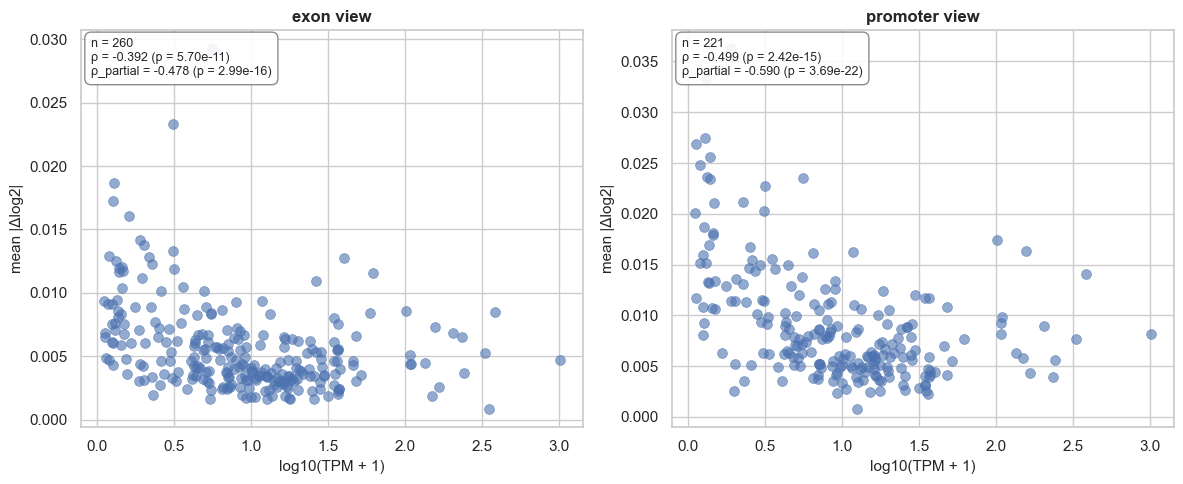

In [186]:
# scatter plots for all three views
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (view_name, mean_col, _, _) in enumerate(views):
    ax = axes[idx]
    
    view_df = df_filt[['log10_tpm1', mean_col, 'gene_length', 'variants_per_kb']].dropna()
    
    if len(view_df) < 10:
        ax.text(0.5, 0.5, f'insufficient data\n(n={len(view_df)})', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{view_name} view', fontweight='bold')
        continue
    
    # get correlation stats
    view_results = results_1_df[
        (results_1_df['view'] == view_name) & 
        (results_1_df['metric'] == 'mean_abs_effect')
    ].iloc[0]
    
    # scatter
    sns.scatterplot(
        x=view_df['log10_tpm1'],
        y=view_df[mean_col],
        s=50,
        alpha=0.6,
        color='#4C72B0',
        edgecolor=None,
        ax=ax
    )
    
    ax.set_xlabel('log10(TPM + 1)', fontsize=11)
    ax.set_ylabel(f'mean |Δlog2|', fontsize=11)
    ax.set_title(f'{view_name} view', fontsize=12, fontweight='bold')
    
    # stats box
    stats_text = (
        f'n = {view_results["n"]:,}\n'
        f'ρ = {view_results["rho"]:.3f} (p = {view_results["p_value"]:.2e})\n'
        f'ρ_partial = {view_results["rho_partial"]:.3f} (p = {view_results["p_partial"]:.2e})'
    )
    
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.9),
        fontsize=9
    )

plt.tight_layout()
plt.show()


Here we show a clear negative relationship between gene expression and perturbation effect size.

Exon view:

As log10(TPM+1) increases, the mean absolute effect steadily drops. Highly expressed genes cluster at very low effect magnitudes, and low-expression genes show a wide spread with many larger effects. The partial correlation confirms this trend is not explained by gene length or variant density.

Promoter view:

The same pattern appears but is even stronger. Low-expression genes show large, variable effects, while high-expression genes consistently show small effects. The partial correlation strengthens further, indicating the expression–effect link is intrinsic rather than a confounding artifact.

Overall the plots support the idea that highly expressed genes exhibit smaller perturbation effects.

## 5. Median of the per-gene mean effect values within each expression bin


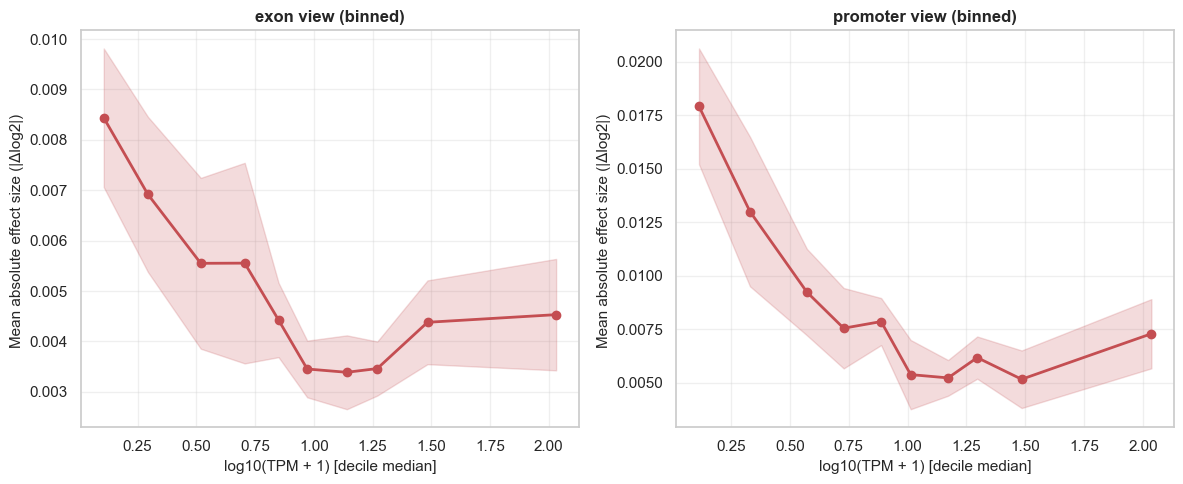

In [142]:
# binned curves: deciles of log10_tpm1 → median mean_abs_effect ± 95% CI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (view_name, mean_col, _, _) in enumerate(views):
    ax = axes[idx]
    
    view_df = df_filt[['log10_tpm1', mean_col]].dropna()
    
    if len(view_df) < 10:
        ax.text(0.5, 0.5, f'insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{view_name} view (binned)', fontweight='bold')
        continue
    
    # compute deciles
    view_df['tpm_decile'] = pd.qcut(view_df['log10_tpm1'], q=10, labels=False, duplicates='drop')
    
    # aggregate per decile
    decile_stats = view_df.groupby('tpm_decile').agg({
        'log10_tpm1': 'median',
        mean_col: ['median', 'sem', 'count']
    }).reset_index()
    
    decile_stats.columns = ['decile', 'median_tpm', 'median_effect', 'sem_effect', 'count']
    
    # 95% CI
    decile_stats['ci_lower'] = decile_stats['median_effect'] - 1.96 * decile_stats['sem_effect']
    decile_stats['ci_upper'] = decile_stats['median_effect'] + 1.96 * decile_stats['sem_effect']
    
    # plot
    ax.plot(decile_stats['median_tpm'], decile_stats['median_effect'], 
            'o-', color='#C44E52', linewidth=2, markersize=6)
    ax.fill_between(
        decile_stats['median_tpm'],
        decile_stats['ci_lower'],
        decile_stats['ci_upper'],
        alpha=0.2,
        color='#C44E52'
    )
    
    ax.set_xlabel('log10(TPM + 1) [decile median]', fontsize=11)
    ax.set_ylabel('Mean absolute effect size (|Δlog2|) ', fontsize=11)
    ax.set_title(f'{view_name} view (binned)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


These binned curves summarize the same effect as the scatterplot

Exon view:

As genes move from low to higher expression deciles (x-axis), the median perturbation effect (y-axis) drops sharply, then flattens around log10(TPM+1) ≈ 1–1.2. The shaded area (95% CI) shrinks with expression, meaning effects are both smaller and less variable for highly expressed genes. The slight rise in the last bins is small and noisy.


Promoter view:
The pattern is even stronger: a steep decline in median effect from the lowest to mid expression deciles, then a shallow plateau at low effect sizes. Again, highly expressed genes show consistently small, tight effects.

So across expression deciles, higher expression is associated with systematically smaller and less variable perturbation effects, especially for promoter perturbations, reinforcing the optimisation hypothesis.

## 6. Outlier exploring

In [143]:
# compute residuals from expression–effect relationship
outlier_df = df_filt[['gene_id', 'log10_tpm1', 'mean_abs_effect_exon', 'tpm', 
                       'gene_length', 'n_variants_exon', 'variants_per_kb',
                       'mean_signed_effect_exon', 'max_variant_score', 
                       'top10pct_effect_fraction', 'cv_effect']].dropna().copy()

# fit linear model to predict effect from expression
from sklearn.linear_model import LinearRegression

X_outlier = outlier_df[['log10_tpm1']].values
y_outlier = outlier_df['mean_abs_effect_exon'].values

model = LinearRegression()
model.fit(X_outlier, y_outlier)
y_pred_outlier = model.predict(X_outlier)

outlier_df['predicted_effect'] = y_pred_outlier
outlier_df['residual'] = y_outlier - y_pred_outlier
outlier_df['abs_residual'] = np.abs(outlier_df['residual'])
outlier_df['z_residual'] = (outlier_df['residual'] - outlier_df['residual'].mean()) / outlier_df['residual'].std()

print(f'outlier analysis: {len(outlier_df):,} genes')
print()
print('residual distribution:')
print(outlier_df['residual'].describe())
print()
print(f'residual mean: {outlier_df["residual"].mean():.6f} (should be ~0)')
print(f'residual std: {outlier_df["residual"].std():.6f}')


outlier analysis: 260 genes

residual distribution:
count    2.600000e+02
mean    -5.337611e-20
std      3.325930e-03
min     -4.830597e-03
25%     -2.098414e-03
50%     -8.796896e-04
75%      1.268927e-03
max      2.327388e-02
Name: residual, dtype: float64

residual mean: -0.000000 (should be ~0)
residual std: 0.003326


In [144]:
# identify outliers (|z-score| > 2.5)
outliers = outlier_df[outlier_df['z_residual'].abs() > 2.5].copy()
outliers = outliers.sort_values('abs_residual', ascending=False)

print(f'identified {len(outliers)} outlier genes (|z| > 2.5):')
print()
print('top outliers (sorted by absolute residual):')
print()
outlier_display = outliers[[
    'gene_id', 'tpm', 'log10_tpm1', 'mean_abs_effect_exon', 
    'predicted_effect', 'residual', 'z_residual',
    'gene_length', 'n_variants_exon', 'variants_per_kb'
]].head(15)
print(outlier_display.to_string(index=False))


identified 6 outlier genes (|z| > 2.5):

top outliers (sorted by absolute residual):

        gene_id       tpm  log10_tpm1  mean_abs_effect_exon  predicted_effect  residual  z_residual  gene_length  n_variants_exon  variants_per_kb
ENSG00000129991  4.534340    0.743066              0.029266          0.005992  0.023274    6.997705       6007.0            14932      2485.766606
ENSG00000156574  2.095500    0.490731              0.023273          0.006535  0.016739    5.032756      16016.0             9870       616.258741
ENSG00000117595  0.284969    0.108893              0.018635          0.007355  0.011279    3.391361      20559.0            10076       490.101659
ENSG00000134571  0.266169    0.102492              0.017243          0.007369  0.009874    2.968710      21297.0            13616       639.338874
ENSG00000157103  0.597970    0.203569              0.016055          0.007152  0.008904    2.677029      47062.0             9112       193.616931
ENSG00000058404 38.855900    1.6

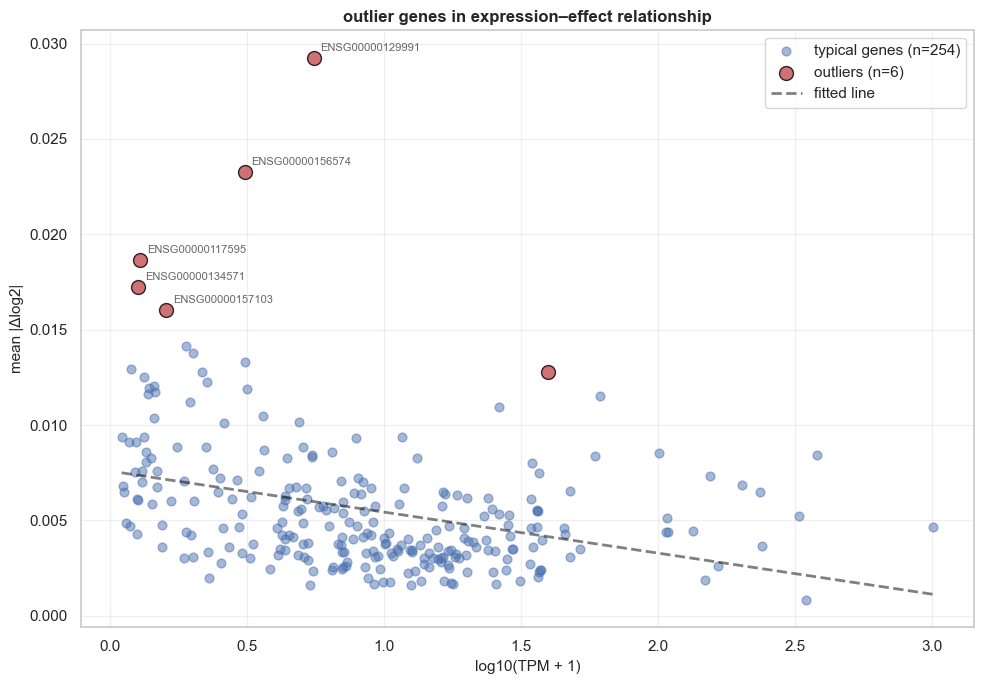

In [145]:
# visualize outliers on scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

# plot non-outliers
non_outliers = outlier_df[outlier_df['z_residual'].abs() <= 2.5]
ax.scatter(
    non_outliers['log10_tpm1'],
    non_outliers['mean_abs_effect_exon'],
    s=40,
    alpha=0.5,
    color='#4C72B0',
    label=f'typical genes (n={len(non_outliers)})',
    edgecolor=None
)

# plot outliers
ax.scatter(
    outliers['log10_tpm1'],
    outliers['mean_abs_effect_exon'],
    s=100,
    alpha=0.8,
    color='#C44E52',
    label=f'outliers (n={len(outliers)})',
    edgecolor='black',
    linewidths=1
)

# add fitted line
x_line = np.linspace(outlier_df['log10_tpm1'].min(), outlier_df['log10_tpm1'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.5, label='fitted line')

# annotate top outliers
top_outliers = outliers.head(5)
for _, row in top_outliers.iterrows():
    ax.annotate(
        row['gene_id'],
        xy=(row['log10_tpm1'], row['mean_abs_effect_exon']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.7
    )

ax.set_xlabel('log10(TPM + 1)', fontsize=11)
ax.set_ylabel('mean |Δlog2|', fontsize=11)
ax.set_title('outlier genes in expression–effect relationship', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [146]:
# characterize outliers: are they different in gene length, variant density, or effect concentration?
print('outlier characteristics compared to typical genes:')
print()

outlier_stats = []
for metric in ['gene_length', 'n_variants_exon', 'variants_per_kb', 
               'top10pct_effect_fraction', 'cv_effect', 'max_variant_score']:
    if metric in outliers.columns and metric in non_outliers.columns:
        outlier_median = outliers[metric].median()
        typical_median = non_outliers[metric].median()
        outlier_mean = outliers[metric].mean()
        typical_mean = non_outliers[metric].mean()
        
        outlier_stats.append({
            'metric': metric,
            'outlier_median': outlier_median,
            'typical_median': typical_median,
            'outlier_mean': outlier_mean,
            'typical_mean': typical_mean,
            'ratio_median': outlier_median / typical_median if typical_median != 0 else float('nan'),
            'ratio_mean': outlier_mean / typical_mean if typical_mean != 0 else float('nan')
        })

outlier_stats_df = pd.DataFrame(outlier_stats)
print(outlier_stats_df.to_string(index=False))


outlier characteristics compared to typical genes:

                  metric  outlier_median  typical_median  outlier_mean  typical_mean  ratio_median  ratio_mean
             gene_length    20928.000000    85803.000000  39250.000000 162455.598425      0.243908    0.241604
         n_variants_exon    10738.000000    11372.000000  11501.000000  13728.960630      0.944249    0.837718
         variants_per_kb      553.180200      144.101384    752.767617    523.722524      3.838826    1.437341
top10pct_effect_fraction        0.629187        0.638274      0.620188      0.641747      0.985763    0.966406
               cv_effect        2.167739        2.266168      2.170166      2.348567      0.956566    0.924038
       max_variant_score       -0.675250       -0.122416     -0.636785     -0.062069      5.516031   10.259376


All of them are positive outliers, they are shorter but more densely mutated

* Gene length: outliers are ~4× shorter than typical genes (median 21 kb vs 86 kb).
* n_variants_exon: only slightly fewer variants per gene.
* ariants_per_kb: therefore much higher density (≈4× higher median).

### 6.1. Do outliers may have extreme single variants driving the mean? Exploriatory since we have 6 genes as outliers 


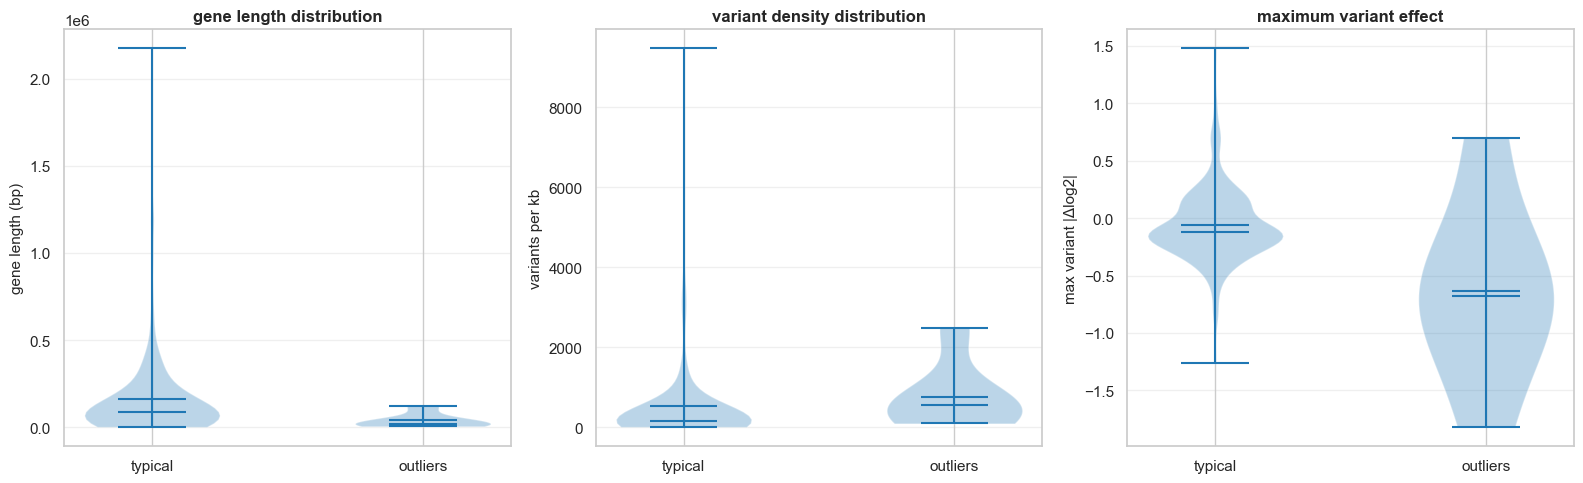

In [147]:
# hypothesis: outliers may have extreme single variants driving the mean
# check max_variant_score distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# gene length
ax = axes[0]
ax.violinplot([non_outliers['gene_length'].values, outliers['gene_length'].values], 
              positions=[1, 2], showmeans=True, showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(['typical', 'outliers'])
ax.set_ylabel('gene length (bp)', fontsize=11)
ax.set_title('gene length distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# variants per kb
ax = axes[1]
ax.violinplot([non_outliers['variants_per_kb'].values, outliers['variants_per_kb'].values], 
              positions=[1, 2], showmeans=True, showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(['typical', 'outliers'])
ax.set_ylabel('variants per kb', fontsize=11)
ax.set_title('variant density distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# max variant score
ax = axes[2]
if 'max_variant_score' in outliers.columns and 'max_variant_score' in non_outliers.columns:
    ax.violinplot([non_outliers['max_variant_score'].values, outliers['max_variant_score'].values], 
                  positions=[1, 2], showmeans=True, showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['typical', 'outliers'])
    ax.set_ylabel('max variant |Δlog2|', fontsize=11)
    ax.set_title('maximum variant effect', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Outlier genes are short, densely mutated, and contain unusually strong single variants, which inflate their mean effect beyond what expression alone would predict.

## 7. Effect concentration (hotspots within genes)

enhancers/promoters often harbor a few dominant nucleotides; concentrated effect burden is expected near key regulatory motifs


concentration analysis: 260 genes with n_variants_exon >= 20

top10pct_effect_fraction:
count    260.000000
mean       0.641249
std        0.060749
min        0.496215
25%        0.603929
50%        0.637441
75%        0.683851
max        0.797806
Name: top10pct_effect_fraction, dtype: float64

cv_effect:
count    260.000000
mean       2.344450
std        0.391458
min        1.650301
25%        2.077348
50%        2.261758
75%        2.507730
max        4.163284
Name: cv_effect, dtype: float64

skewness_effect:
count    260.000000
mean       6.081769
std        3.846297
min        2.687135
25%        4.157494
50%        5.163255
75%        6.544272
max       45.816665
Name: skewness_effect, dtype: float64


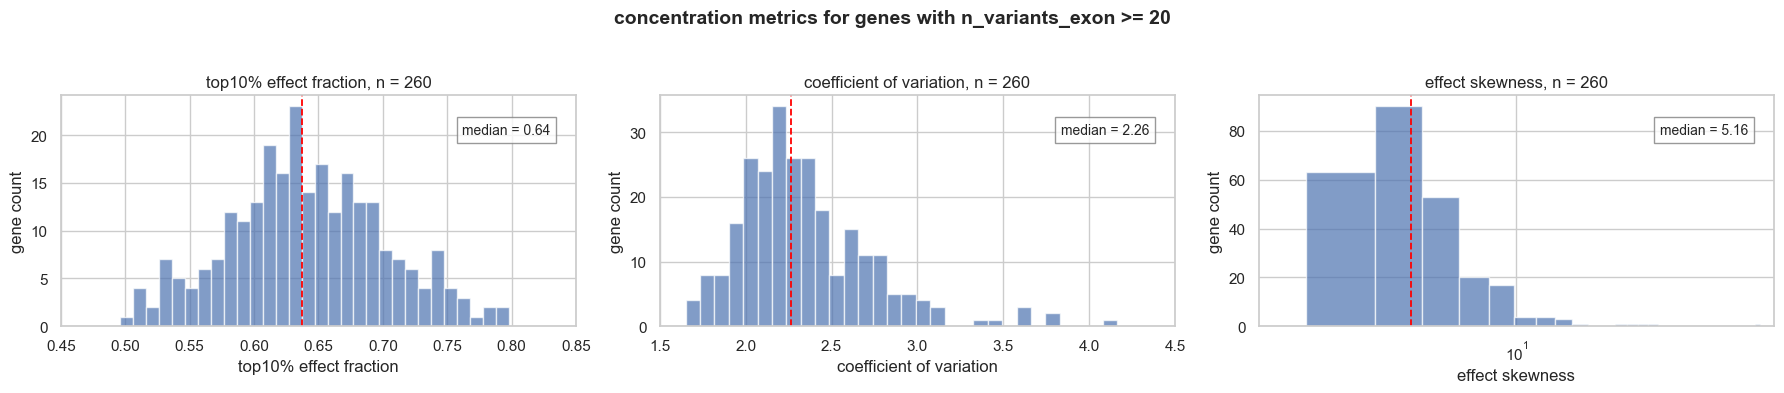

In [148]:
# concentration metrics: top10pct_effect_fraction, cv_effect, skewness_effect
conc_df = df_filt[
    (df_filt['n_variants_exon'] >= 20) &
    df_filt['top10pct_effect_fraction'].notna() &
    df_filt['cv_effect'].notna() &
    df_filt['skewness_effect'].notna()
].copy()

print(f'concentration analysis: {len(conc_df):,} genes with n_variants_exon >= 20')
print()
print('top10pct_effect_fraction:')
print(conc_df['top10pct_effect_fraction'].describe())
print()
print('cv_effect:')
print(conc_df['cv_effect'].describe())
print()
print('skewness_effect:')
print(conc_df['skewness_effect'].describe())


fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_specs = [
    ('top10pct_effect_fraction', 'top10% effect fraction', (0.45, 0.85), False),
    ('cv_effect', 'coefficient of variation', (1.5, 4.5), False),
    ('skewness_effect', 'effect skewness', (2.0, 50.0), True),
]

for ax, (col, title, xlim, log_scale) in zip(axes, plot_specs):
    values = conc_df[col].dropna()
    ax.hist(values, bins=30, color='#4C72B0', alpha=0.7, edgecolor='white')
    median_val = values.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.3)
    ax.text(0.95, 0.85, f'median = {median_val:.2f}', transform=ax.transAxes,
            ha='right', va='center', fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    if log_scale:
        ax.set_xscale('log')
    ax.set_xlim(*xlim)
    ax.set_xlabel(title)
    ax.set_ylabel('gene count')
    ax.set_title(f'{title}, n = {len(values):,}')

plt.suptitle('concentration metrics for genes with n_variants_exon >= 20', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


1. Top-10% effect fraction
* Most genes have 0.60–0.70 of their total regulatory effect concentrated in the strongest 10% of variants.
* This supports the idea of regulatory hotspots: a small subset of positions carries most of the regulatory burden.

2. Coefficient of variation (CV) of effects

* CV ≈ 2.0–2.5 for most genes, indicating large variability in effect sizes within each gene.
* This again suggests that most variants are weak, with a minority showing disproportionately large effects.

3. Skewness of effects 

* Skewness is highly right-tailed: median ≈ 5, but some genes reach 20–45.
* This means many genes have long tails of rare large-effect variants, consistent with sparse motif-like sensitivity regions.



Across genes, exon variant effects are highly concentrated and strongly right-skewed:
a small fraction of variants (∼10%) accounts for most of the regulatory impact, consistent with the idea of regulatory hotspots near key motifs.

### 7.1. Concentration metrics correlation with expression

In [149]:
# Correlations with expression
metrics_conc = ['top10pct_effect_fraction', 'cv_effect', 'skewness_effect']

print('concentration metrics vs log10_tpm1:')
print()
for metric in metrics_conc:
    rho, p = spearmanr(conc_df['log10_tpm1'], conc_df[metric])
    print(f'{metric}: ρ = {rho:.3f}, p = {p:.2e}')

print()
print('concentration metrics vs gene_length (partialling log10_tpm1):')
print()
for metric in metrics_conc:
    rho_partial, p_partial = partial_spearman(
        conc_df[metric].values,
        conc_df['gene_length'].values,
        conc_df['log10_tpm1'].values
    )
    print(f'{metric}: ρ_partial = {rho_partial:.3f}, p = {p_partial:.2e}')

print()
print('concentration metrics vs variants_per_kb (partialling log10_tpm1):')
print()
for metric in metrics_conc:
    rho_partial, p_partial = partial_spearman(
        conc_df[metric].values,
        conc_df['variants_per_kb'].values,
        conc_df['log10_tpm1'].values
    )
    print(f'{metric}: ρ_partial = {rho_partial:.3f}, p = {p_partial:.2e}')


concentration metrics vs log10_tpm1:

top10pct_effect_fraction: ρ = -0.040, p = 5.19e-01
cv_effect: ρ = -0.047, p = 4.53e-01
skewness_effect: ρ = -0.079, p = 2.03e-01

concentration metrics vs gene_length (partialling log10_tpm1):

top10pct_effect_fraction: ρ_partial = -0.007, p = 9.12e-01
cv_effect: ρ_partial = -0.127, p = 4.05e-02
skewness_effect: ρ_partial = -0.251, p = 4.16e-05

concentration metrics vs variants_per_kb (partialling log10_tpm1):

top10pct_effect_fraction: ρ_partial = 0.096, p = 1.21e-01
cv_effect: ρ_partial = 0.198, p = 1.31e-03
skewness_effect: ρ_partial = 0.254, p = 3.34e-05


How concentrated the effects are within a gene does not depend on expression level.

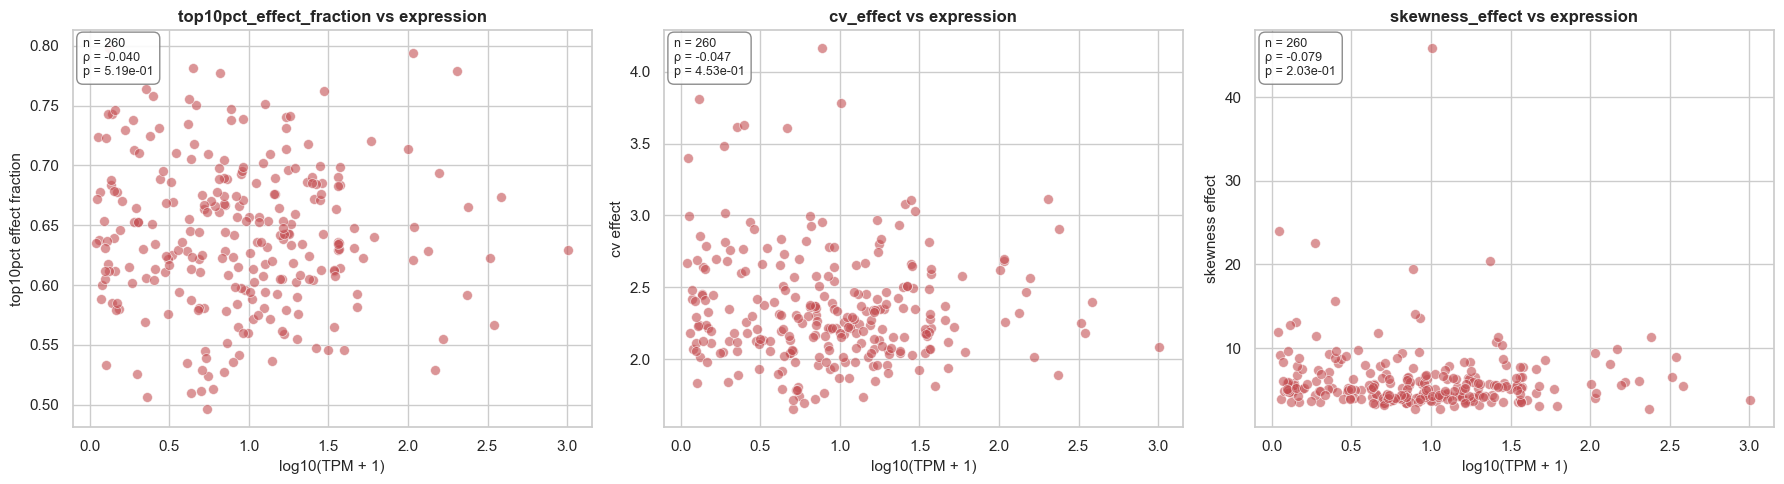

In [150]:
# scatter plots for concentration metrics vs log10_tpm1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(metrics_conc):
    ax = axes[idx]
    
    rho, p = spearmanr(conc_df['log10_tpm1'], conc_df[metric])
    
    sns.scatterplot(
        x=conc_df['log10_tpm1'],
        y=conc_df[metric],
        s=50,
        alpha=0.6,
        color='#C44E52',
        ax=ax
    )
    
    ax.set_xlabel('log10(TPM + 1)', fontsize=11)
    ax.set_ylabel(metric.replace('_', ' '), fontsize=11)
    ax.set_title(f'{metric} vs expression', fontsize=12, fontweight='bold')
    
    stats_text = f'n = {len(conc_df):,}\nρ = {rho:.3f}\np = {p:.2e}'
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.9),
        fontsize=9
    )

plt.tight_layout()
plt.show()


Again, there is no correlation between expression and any concentration metric

### 7.2. Compare gene length across effect quartiles


gene length summary by effect quartile:
Q1 (lowest): n=65, median=122516, iqr=(55527, 192136)
Q2: n=65, median=109293, iqr=(42680, 199051)
Q3: n=65, median=83993, iqr=(36316, 187141)
Q4 (highest): n=65, median=42645, iqr=(16737, 96646)

spearman(mean_abs_effect_exon, gene_length) = -0.285 (p = 3.05e-06)
partial spearman (controlling log10_tpm1) = -0.408 (p = 7.19e-12)


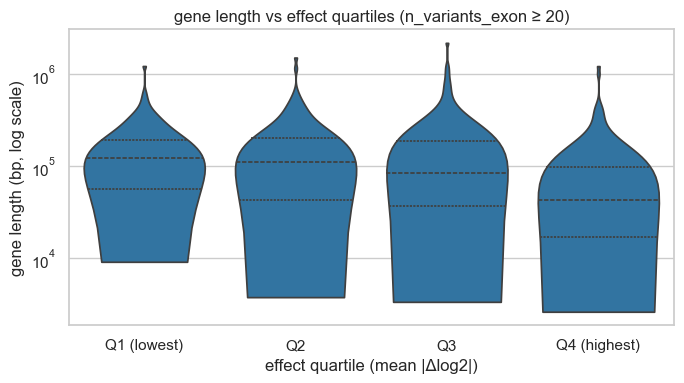

In [151]:
if 'mean_abs_effect_exon' not in conc_df.columns:
    raise KeyError('mean_abs_effect_exon required for quartile comparison')

length_df = conc_df.dropna(subset=['mean_abs_effect_exon', 'gene_length']).copy()
quartile_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
length_df['effect_quartile'] = pd.qcut(
    length_df['mean_abs_effect_exon'],
    q=4,
    labels=quartile_labels,
    duplicates='drop'
)

print()
print('gene length summary by effect quartile:')
for label in quartile_labels:
    subset = length_df.loc[length_df['effect_quartile'] == label, 'gene_length']
    if subset.empty:
        continue
    print(f"{label}: n={len(subset):,}, median={subset.median():.0f}, iqr=({subset.quantile(0.25):.0f}, {subset.quantile(0.75):.0f})")

rho_len, p_len = spearmanr(length_df['mean_abs_effect_exon'], length_df['gene_length'])
print()
print(f'spearman(mean_abs_effect_exon, gene_length) = {rho_len:.3f} (p = {p_len:.2e})')

partial_df = length_df.dropna(subset=['log10_tpm1']) if 'log10_tpm1' in length_df.columns else length_df
if 'log10_tpm1' in partial_df.columns and len(partial_df) >= 3:
    rho_partial, p_partial = partial_spearman(
        partial_df['mean_abs_effect_exon'].values,
        partial_df['gene_length'].values,
        partial_df['log10_tpm1'].values
    )
    print(f'partial spearman (controlling log10_tpm1) = {rho_partial:.3f} (p = {p_partial:.2e})')

fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(
    data=length_df,
    x='effect_quartile',
    y='gene_length',
    order=quartile_labels,
    cut=0,
    scale='width',
    inner='quartile',
    ax=ax
)
ax.set_yscale('log')
ax.set_xlabel('effect quartile (mean |Δlog2|)')
ax.set_ylabel('gene length (bp, log scale)')
ax.set_title('gene length vs effect quartiles (n_variants_exon ≥ 20)')
plt.tight_layout()
plt.show()

### 7.3. Effect size against both expression and gene length
does gene length predict effect size after controlling for expression?

data points: 260
spearman(effect, log_gene_length) = -0.285 (p = 3.05e-06)
partial spearman effect~log_gene_length | log10_tpm1 = -0.408 (p = 7.19e-12)
linear model: effect = 0.0209 + -0.0028*log10_tpm1 + -0.0026*log_gene_length


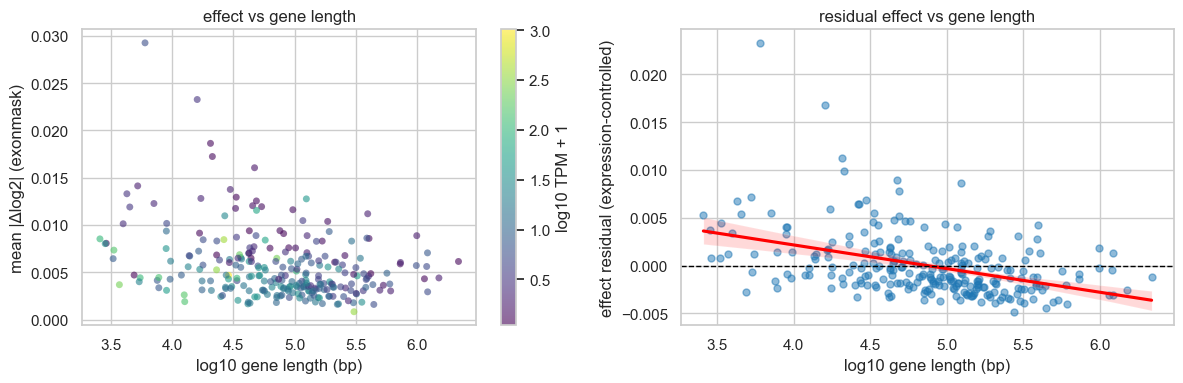

In [ ]:
reg_df = df_filt[['mean_abs_effect_exon', 'log10_tpm1', 'gene_length']].dropna().copy()

reg_df['log_gene_length'] = np.log10(reg_df['gene_length'])

rho_len, p_len = spearmanr(reg_df['log_gene_length'], reg_df['mean_abs_effect_exon'])
rho_partial, p_partial = partial_spearman(
    reg_df['mean_abs_effect_exon'].values,
    reg_df['log_gene_length'].values,
    reg_df['log10_tpm1'].values
)

expr_only_model = LinearRegression().fit(
    reg_df[['log10_tpm1']], reg_df['mean_abs_effect_exon']
)
reg_df['effect_residual_expr'] = (
    reg_df['mean_abs_effect_exon'] - expr_only_model.predict(reg_df[['log10_tpm1']])
)

full_model = LinearRegression().fit(
    reg_df[['log10_tpm1', 'log_gene_length']],
    reg_df['mean_abs_effect_exon']
)
coef_expr, coef_length = full_model.coef_
intercept = full_model.intercept_

print(f'data points: {len(reg_df):,}')
print(f"spearman(effect, log_gene_length) = {rho_len:.3f} (p = {p_len:.2e})")
print(f"partial spearman effect~log_gene_length | log10_tpm1 = "
      f"{rho_partial:.3f} (p = {p_partial:.2e})")
print(f'linear model: effect = {intercept:.4f} '
      f'+ {coef_expr:.4f}*log10_tpm1 '
      f'+ {coef_length:.4f}*log_gene_length')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

scatter = axes[0].scatter(
    reg_df['log_gene_length'],
    reg_df['mean_abs_effect_exon'],
    c=reg_df['log10_tpm1'],
    cmap='viridis',
    alpha=0.6,
    s=25,
    edgecolor='none'
)
axes[0].set_xlabel('log10 gene length (bp)')
axes[0].set_ylabel('mean |Δlog2| (exonmask)')
axes[0].set_title('effect vs gene length')
cb = fig.colorbar(scatter, ax=axes[0])
cb.set_label('log10 TPM + 1')

sns.regplot(
    ax=axes[1],
    x='log_gene_length',
    y='effect_residual_expr',
    data=reg_df,
    scatter_kws={'alpha': 0.5, 's': 25},
    line_kws={'color': 'red'}
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('log10 gene length (bp)')
axes[1].set_ylabel('effect residual (expression-controlled)')
axes[1].set_title('residual effect vs gene length')

plt.tight_layout()
plt.show()

1.	Raw correlation (Spearman): effect vs gene_length: ρ = –0.285, p ≈ 3×10⁻⁶  Across genes, shorter genes tend to have larger exonmask effects. The effect is moderate but non-random.

2.	Partial correlation (controlling for expression). effect vs gene_length | log10_tpm1: ρ_partial = –0.408, p ≈ 7×10⁻¹²
Once we remove the influence of expression, the relationship between effect and gene length actually becomes stronger.

So gene length is not just a proxy for expression but carries independent information about effect magnitude.
	3.	Linear model
* higher expression have smaller effect (our main buffering result),
* longer genes have smaller effect, even after accounting for expression.

* We now have two independent predictors of smaller exonmask effects higher gene expression and longer gene length.
OR short, moderately/lowly expressed genes are the ones with the largest perturbation effects.


## TODO: (A) Does promoter architecture modulate buffering?

Test correlations between:
	•	TATA vs non-TATA
	•	CpG-high vs CpG-low
	•	number of TF motifs
	•	H3K4me3 width
and effect magnitude.

This could test if promoter robustness relates to expression buffering.

## TODO: (B) Do promoter features relate to effect concentration?

Ask if certain promoter classes produce more “hotspotty” exon regulation.

## 8. Gene lenght and adding also variant density

larger genes or denser variant sets mechanically raise the chance of extreme scores; residual trends isolating expression effects indicate biological rather than combinatorial signal


In [153]:
# correlations: mean_abs_effect_exon vs gene_length and variants_per_kb
conf_df = df_filt[['mean_abs_effect_exon', 'gene_length', 'variants_per_kb', 'log10_tpm1']].dropna()

# raw correlations
rho_length, p_length = spearmanr(conf_df['mean_abs_effect_exon'], conf_df['gene_length'])
rho_density, p_density = spearmanr(conf_df['mean_abs_effect_exon'], conf_df['variants_per_kb'])

# partial correlations (partialling log10_tpm1)
rho_length_partial, p_length_partial = partial_spearman(
    conf_df['mean_abs_effect_exon'].values,
    conf_df['gene_length'].values,
    conf_df['log10_tpm1'].values
)

rho_density_partial, p_density_partial = partial_spearman(
    conf_df['mean_abs_effect_exon'].values,
    conf_df['variants_per_kb'].values,
    conf_df['log10_tpm1'].values
)

print(f'mean_abs_effect_exon vs gene_length:')
print(f'  raw: ρ = {rho_length:.3f}, p = {p_length:.2e}')
print(f'  partial (controlling log10_tpm1): ρ = {rho_length_partial:.3f}, p = {p_length_partial:.2e}')
print()
print(f'mean_abs_effect_exon vs variants_per_kb:')
print(f'  raw: ρ = {rho_density:.3f}, p = {p_density:.2e}')
print(f'  partial (controlling log10_tpm1): ρ = {rho_density_partial:.3f}, p = {p_density_partial:.2e}')


mean_abs_effect_exon vs gene_length:
  raw: ρ = -0.285, p = 3.05e-06
  partial (controlling log10_tpm1): ρ = -0.408, p = 7.19e-12

mean_abs_effect_exon vs variants_per_kb:
  raw: ρ = 0.239, p = 1.01e-04
  partial (controlling log10_tpm1): ρ = 0.363, p = 1.67e-09


Even after controlling for expression, longer genes have systematically smaller exon effects; shorter genes have larger effects. The partial correlation being stronger than the raw one means expression was actually masking some of that relationship.

After controlling for expression, genes with higher variant density per kb show larger average exon effects. Again, the partial correlation is stronger, so expression was dampening this signal.

* Short, densely mutated genes tend to have larger mean exonmask effects.
* Long, sparsely mutated genes tend to have smaller effects.

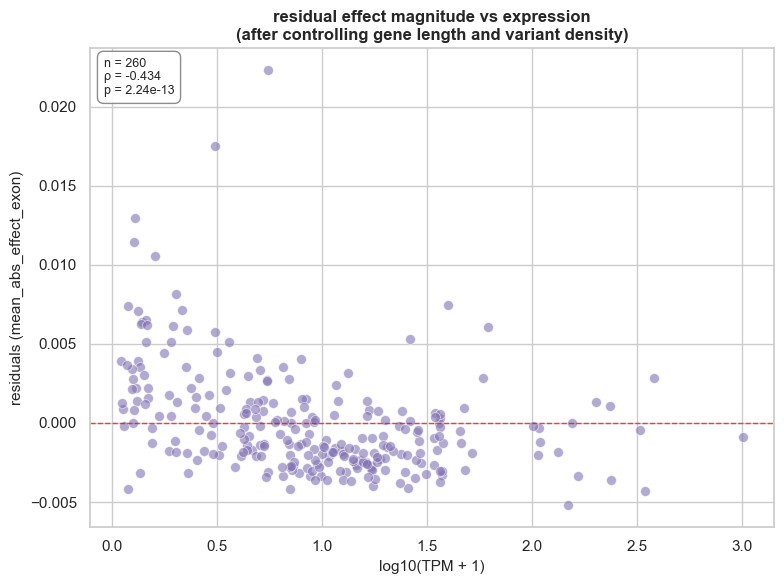

In [154]:
# residual analysis: regress mean_abs_effect_exon ~ gene_length + variants_per_kb
X = np.column_stack([
    np.ones(len(conf_df)),
    conf_df['gene_length'].values,
    conf_df['variants_per_kb'].values
])

y = conf_df['mean_abs_effect_exon'].values

# fit linear model
beta = np.linalg.lstsq(X, y, rcond=None)[0]
y_pred = X @ beta
residuals = y - y_pred

conf_df['residuals'] = residuals

# plot residuals vs log10_tpm1
fig, ax = plt.subplots(figsize=(8, 6))

rho_resid, p_resid = spearmanr(conf_df['log10_tpm1'], conf_df['residuals'])

sns.scatterplot(
    x=conf_df['log10_tpm1'],
    y=conf_df['residuals'],
    s=50,
    alpha=0.6,
    color='#8172B3',
    ax=ax
)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('log10(TPM + 1)', fontsize=11)
ax.set_ylabel('residuals (mean_abs_effect_exon)', fontsize=11)
ax.set_title('residual effect magnitude vs expression\n(after controlling gene length and variant density)', 
             fontsize=12, fontweight='bold')

stats_text = f'n = {len(conf_df):,}\nρ = {rho_resid:.3f}\np = {p_resid:.2e}'
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    ha='left', va='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.9),
    fontsize=9
)

plt.tight_layout()
plt.show()


Even after accounting for gene length and how many variants a gene carries, highly expressed genes still show smaller effects. SO long genes do not explain the pattern, nor the desnce-variant genes. 

## 9. Signed-effect sanity check

**justification**: across random local variants, up/down effects should average near zero; a strong directional bias can indicate assay/model skew


signed-effect global summary (n=260 genes):
  mean: -0.000236
  median: -0.000093
  std: 0.001203

one-sample t-test vs 0:
  t = -3.165, p = 1.74e-03


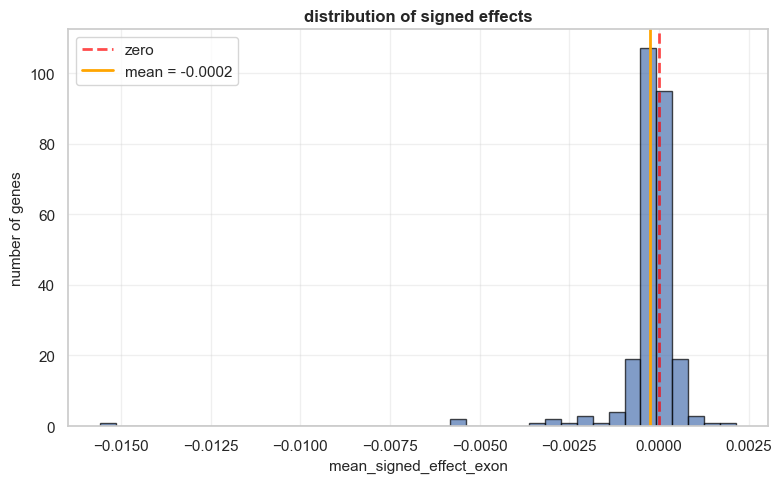

In [ ]:
signed_df = df_filt[df_filt['mean_signed_effect_exon'].notna()].copy()

global_mean_signed = signed_df['mean_signed_effect_exon'].mean()
global_median_signed = signed_df['mean_signed_effect_exon'].median()

# one-sample t-test vs 0
t_stat, p_ttest = stats.ttest_1samp(signed_df['mean_signed_effect_exon'], 0)

print(f'signed-effect global summary (n={len(signed_df):,} genes):')
print(f'  mean: {global_mean_signed:.6f}')
print(f'  median: {global_median_signed:.6f}')
print(f'  std: {signed_df["mean_signed_effect_exon"].std():.6f}')
print()
print(f'one-sample t-test vs 0:')
print(f'  t = {t_stat:.3f}, p = {p_ttest:.2e}')

# histogram
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(signed_df['mean_signed_effect_exon'], bins=40, color='#4C72B0', alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='zero')
ax.axvline(x=global_mean_signed, color='orange', linestyle='-', linewidth=2, label=f'mean = {global_mean_signed:.4f}')

ax.set_xlabel('mean_signed_effect_exon', fontsize=11)
ax.set_ylabel('number of genes', fontsize=11)
ax.set_title('distribution of signed effects', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [187]:
bias_threshold = 0.01
bias_df = signed_df[
    (signed_df['n_variants_exon'] >= 20) &
    (signed_df['mean_signed_effect_exon'].abs() >= bias_threshold)
].copy()

print(f'genes with |mean_signed_effect_exon| >= {bias_threshold} and n_variants_exon >= 20:')
print(f'  n = {len(bias_df)} ({100 * len(bias_df) / len(signed_df):.1f}% of total)')
print()

if len(bias_df) > 0:
    print('top-10 biased genes (by absolute signed effect):')
    print()
    bias_top10 = bias_df.nlargest(10, 'mean_signed_effect_exon', keep='all')[[
        'gene_id', 'mean_signed_effect_exon', 'mean_abs_effect_exon', 
        'n_variants_exon', 'log10_tpm1'
    ]]
    print(bias_top10.to_string(index=False))


genes with |mean_signed_effect_exon| >= 0.01 and n_variants_exon >= 20:
  n = 1 (0.4% of total)

top-10 biased genes (by absolute signed effect):

        gene_id  mean_signed_effect_exon  mean_abs_effect_exon  n_variants_exon  log10_tpm1
ENSG00000129991                 -0.01559              0.029266            14932    0.743066


Cardiac muscle 

### 10. Windows (−2 kb vs −10 kb vs −100 kb)

**Justification**: sharp promoter peaks (−2 kb >> −10 kb >> −100 kb) imply promoter-centric regulation


In [159]:
up_df = df_filt[
    ['mean_abs_effect_up2kb', 'mean_abs_effect_up10kb', 'mean_abs_effect_up100kb',
     'enrich_up_vs_down_2kb', 'enrich_up_vs_intron_2kb']
].dropna()

print('n genes for upstream window analysis:', len(up_df))
print()

for col in ['mean_abs_effect_up2kb', 'mean_abs_effect_up10kb', 'mean_abs_effect_up100kb']:
    s = up_df[col]
    print(f'{col}: median={s.median():.4f}, iqr=({s.quantile(0.25):.4f}, {s.quantile(0.75):.4f})')

print()
for col in ['enrich_up_vs_down_2kb', 'enrich_up_vs_intron_2kb']:
    s = up_df[col]
    frac_gt1 = (s > 1).mean()
    print(f'{col}: median={s.median():.2f}, fraction>1 = {frac_gt1:.2%}')

n genes for upstream window analysis: 218

mean_abs_effect_up2kb: median=0.0053, iqr=(0.0029, 0.0087)
mean_abs_effect_up10kb: median=0.0042, iqr=(0.0023, 0.0063)
mean_abs_effect_up100kb: median=0.0042, iqr=(0.0023, 0.0063)

enrich_up_vs_down_2kb: median=0.52, fraction>1 = 12.39%
enrich_up_vs_intron_2kb: median=0.52, fraction>1 = 12.39%


So there is only a small increase at −2 kb vs −10/−100 kb. It is not a strong hierarchy like “−2 kb >> −10 kb >> −100 kb”. The curves are basically flat with a slight bump at −2 kb.

## 11. Supplementary: GTEx v7 gene expression (TPM), aggregated and standardized

* Alphagenome: a per-gene aggregate effect size (mean_abs_effect_exon or median_abs_effect_exon)

We want to know if genes that are predicted to be highly expressed from promoter sequence also show large/small average perturbation effects in Alphagenome?”

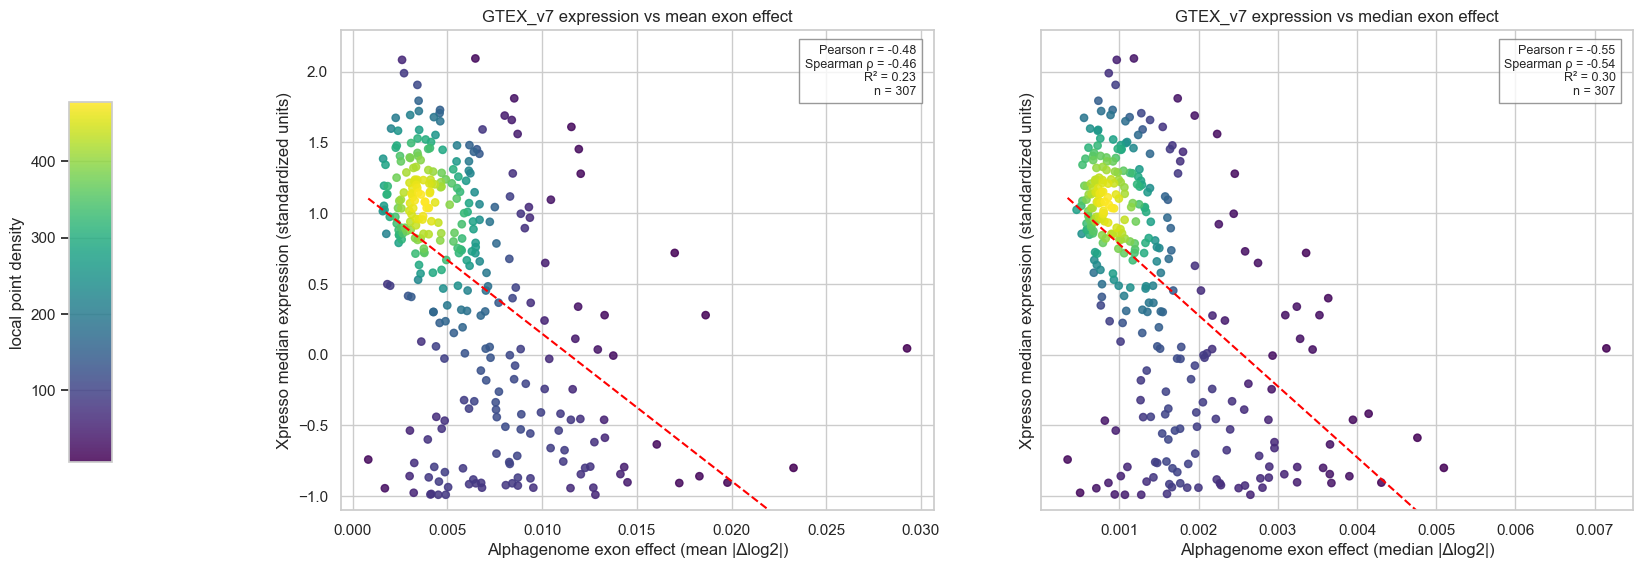

In [188]:
GTEX_v7 = "/Users/markus/university/ML-in-biotech-CB206V-ws25/data/initial/datasets/TableS1_human.txt"
ALPHAGENOME_DATASET = "/Users/markus/university/ML-in-biotech-CB206V-ws25/data/results/ClinGen/gene_level_data_extended.csv"

# Xpresso
xpresso_df = (
    pd.read_csv(GTEX_v7, sep="\t", usecols=["a$gene_id", "medianExpr"])
      .rename(columns={"a$gene_id": "gene_id", "medianExpr": "median_expression"})
)
xpresso_df["gene_id"] = xpresso_df["gene_id"].astype(str).str.split(".").str[0]
xpresso_df["median_expression"] = pd.to_numeric(xpresso_df["median_expression"], errors="coerce")

# Alphagenome
alphagenome_df = pd.read_csv(
    ALPHAGENOME_DATASET,
    usecols=["gene_id", "mean_abs_effect_exon", "median_abs_effect_exon"]
)
alphagenome_df["gene_id"] = alphagenome_df["gene_id"].astype(str).str.split(".").str[0]

merged = xpresso_df.merge(alphagenome_df, on="gene_id", how="inner").dropna()
merged["expr_xpresso"] = merged["median_expression"]  # already standardized log expression

def make_panel(ax, x, y, xlabel, title):

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    idx = np.argsort(z)
    x, y, z = x[idx], y[idx], z[idx]

    sc = ax.scatter(x, y, c=z, s=28, cmap="viridis", alpha=0.85)

    # regression line
    coef = np.polyfit(x, y, deg=1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, np.polyval(coef, xs), "r--", linewidth=1.5)

    # stats
    r_pear, _ = pearsonr(x, y)
    rho_spear, _ = spearmanr(x, y)
    r2 = r_pear**2

    stats_text = (
        f"Pearson r = {r_pear:.2f}\n"
        f"Spearman ρ = {rho_spear:.2f}\n"
        f"R² = {r2:.2f}\n"
        f"n = {len(x):,}"
    )

    ax.text(
        0.97, 0.97, stats_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8)
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Xpresso median expression (standardized units)")
    ax.set_title(title)

    # crop y-axis (e.g. from -1.1 to max data + margin)
    ax.set_ylim(-1.1, y.max() + 0.2)

    return sc

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

# mean effect
make_panel(
    ax=axes[0],
    x=merged["mean_abs_effect_exon"].values,
    y=merged["expr_xpresso"].values,
    xlabel="Alphagenome exon effect (mean |Δlog2|)",
    title="GTEX_v7 expression vs mean exon effect"
)

# median effect
sc2 = make_panel(
    ax=axes[1],
    x=merged["median_abs_effect_exon"].values,
    y=merged["expr_xpresso"].values,
    xlabel="Alphagenome exon effect (median |Δlog2|)",
    title="GTEX_v7 expression vs median exon effect"
)

fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.92, wspace=0.18)
cbar_ax = fig.add_axes([0.06, 0.2, 0.025, 0.6])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.ax.yaxis.set_ticks_position("left")
cbar.ax.yaxis.set_label_position("left")
cbar.set_label("local point density")

plt.show()

So if we would to ask if genes that are broadly highly expressed across human tissues (GTEx) tend to be more or less sensitive to local coding perturbations in our assay then they are less sensitive
